In [48]:

#TP_3_BROADCASTING Eléonore Veyron 


import numpy as np
import matplotlib.pyplot as plt

#%matplotlib ipympl

In [7]:

#Echauffement : le broadcasting

a = np.array([1,2,3]) # shape de a = (3)

print(a[:,None], a[:,None].shape)
print(a[None,:], a[None,:].shape)

#1. a[:,None] de shape (3,1), rajoute une dimension "vers la droite" à a
#   a[None,:] de shape (1,3) rajoute une dimension "vers la gauche" à a

#2 Elle sera de la forme (3,3) 
# L'élément [i,j] contient a[:,None][i][1] - a[None,:][1][j]

b=np.array([[1,2,3],[4,5,6]])

#3 b[:,None,:] est de taille (2,1,3) 
# b[:,:,None] est de taille (2,3,1)
# b[:,None,:] - b[:,:,None] va être de taille (2,3,3)
# Avec d = b[:,None,:] - b[:,:,None]
# d[i,j,k] renvoit à b[:,None,:][i][1][k] - b[:,:,None][i][j][1] 
# si on renvoit avec les éléments de b :
#d[i,j,k] = b[i][k]-b[i][j]

[[1]
 [2]
 [3]] (3, 1)
[[1 2 3]] (1, 3)


In [52]:
# Initialisation aléatoire

# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.

#:tags: [level_basic]

# votre code
#on suppose min_max=0

def init_problem(N):
    """
    retourne un tuple masses, positions, speeds
    de formes resp.   (N,)    (2, N)     (2, N)
    tiré au sort dans les bornes définies ci-dessus
    """
    masses = np.random.uniform(0.1,mass_max, (N,))
    low=np.array([[x_min],[y_min]])
    high=np.array([[x_max],[y_max]])
    positions = np.random.uniform(low,high,(2,N))
    speeds = np.random.uniform(-speed_max,speed_max,(2,N))
    return masses, positions, speeds

masses,positions,speeds = init_problem(5)

In [4]:
#Initialisationreproductible

# for your convenience

def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds


In [ ]:
# Les forces 

def forces(masses, positions, G=1.0):
    """
    returns an array of shape (2,  N)
    that contains the force felt by each mass from all the others
    G is the Newton constant and by default is set to 1 
    (we have abstract units anyway)
    """
    r= positions[:,:,None]-positions[:,None,:]
    d= np.linalg.norm(r,axis=0)
    np.fill_diagonal(d,np.inf)
    M= masses[:,None]*masses[None,:]
    coef = G * M
    C=coef[None,:,:]
    F=np.sum(C*r/(d**3),axis=1) # on somme sur la ligne
    
    return F

print(forces(init3()[0], init3()[1]))



[[ 0.         -0.12257258  0.12257258]
 [ 0.         -0.02451452  0.02451452]]


In [35]:
#Le Simulateur


def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    """
    should return the positions across time
    so an array of shape (nb_steps, 2, N)
    optional dt is the time step
    """
    N=len(masses)
    dim=len(positions)
    res =np.zeros((nb_steps,dim,N))
    m=masses[None,:]
    for i in range(nb_steps):
        res[i]=positions
        F=forces(masses,positions)
        a= F/m
        speeds=speeds+a*dt
        positions=positions + speeds*dt
    res[-1]=positions 
    return res
simulate1=simulate(init3()[0],init3()[1],init3()[2])
print(simulate1)


[[[ 0.          5.         -5.        ]
  [ 0.          1.         -1.        ]]

 [[ 0.          4.89877427 -4.89877427]
  [ 0.          0.99975485 -0.99975485]]

 [[ 0.          4.79627468 -4.79627468]
  [ 0.          0.99924973 -0.99924973]]

 [[ 0.          4.69244953 -4.69244953]
  [ 0.          0.99846845 -0.99846845]]

 [[ 0.          4.58724324 -4.58724324]
  [ 0.          0.99739329 -0.99739329]]

 [[ 0.          4.48059587 -4.48059587]
  [ 0.          0.99600479 -0.99600479]]

 [[ 0.          4.37244262 -4.37244262]
  [ 0.          0.99428155 -0.99428155]]

 [[ 0.          4.26271324 -4.26271324]
  [ 0.          0.99219989 -0.99219989]]

 [[ 0.          4.15133136 -4.15133136]
  [ 0.          0.98973361 -0.98973361]]

 [[ 0.          4.03821371 -4.03821371]
  [ 0.          0.98685348 -0.98685348]]

 [[ 0.          3.92326914 -3.92326914]
  [ 0.          0.9835269  -0.9835269 ]]

 [[ 0.          3.80639758 -3.80639758]
  [ 0.          0.97971724 -0.97971724]]

 [[ 0.          

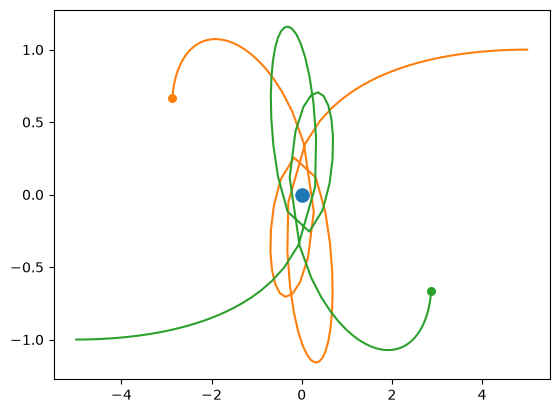

In [ ]:
#Dessiner

def draw(simulation, masses, colors=None, scale=10.):
    """
    takes as input the result of simulate() above,
    and draws the nb_steps positions of each of the N bodies
    ideally it should return a matplotlib Axes object

    one can provide a collection of N colors to use for each body
    if not provided this is randomized

    also the optional scale parameter is used as a constant
    multiplier to obtain the final size of each dot on the figure
    """
    fig, ax = plt.subplots()
    for i in range(len(masses)):
        x=simulation[:,:,i].T[0]
        y=simulation[:,:,i].T[1]
        ax.scatter(x[-1],y[-1], s=30*masses[i])
        if colors !=None:
            plt.plot(x,y,color=colors[i])
        else:
            plt.plot(x,y)
    
    plt.show()

draw(simulate1,init3()[0])
#simulation[:, :, i] représente la position de l'objet i au cours du temps 
#simulation[:, :, i].T  représente deux tableaux avec les x et les y de l'objet i 


In [55]:
#Un jeu de couleur

colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255


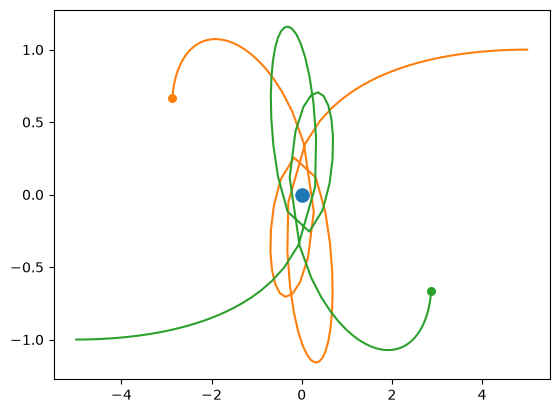

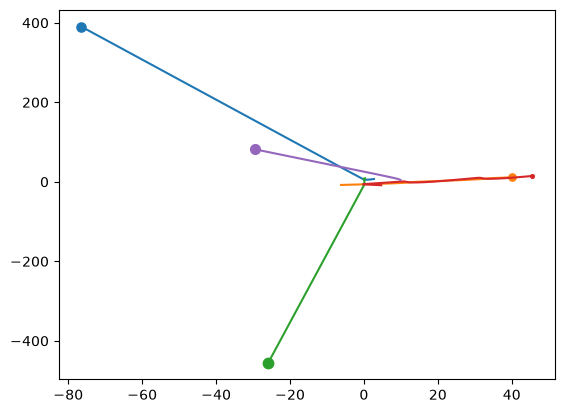

<Figure size 640x480 with 0 Axes>

In [63]:
#On assemble le tout 


masses, positions, speeds = init3()
draw(simulate(masses, positions, speeds), masses, colors3)

m5, p5, s5 = init_problem(5)
sim5 = simulate(m5, p5, s5, nb_steps=1000)
draw(sim5, m5, scale=3);
plt.savefig("random5.png")



In [ ]:
#Partie optionnelle